Для инференса моделей используется vLLM сервер, работающий на двух 5060ti по 16gb каждая. Для запуска каждой модели написаны bash файлы с командами.
Перед запуском проверки необходимо запустить vllm с нужной моделью и проводить инференс.

Запуск:

- `start_qwen.sh`
- `start_intern.sh`

In [4]:
import os
import requests
from io import BytesIO
import base64
import json

from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import ast
import tempfile
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

from datasets import load_dataset
from openai import OpenAI
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
from sentence_transformers import SentenceTransformer, util

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [5]:
RANDOM_SEED=42

# EDA

In [6]:
data = load_dataset("milistu/AMAZON-Products-2023")['train']
data

Dataset({
    features: ['parent_asin', 'date_first_available', 'title', 'description', 'filename', 'main_category', 'categories', 'store', 'average_rating', 'rating_number', 'price', 'features', 'details', 'embeddings', 'image', '__index_level_0__'],
    num_rows: 117243
})

In [7]:
# Структура данных
df = data.to_pandas()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117243 entries, 0 to 117242
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   parent_asin           117243 non-null  object        
 1   date_first_available  117243 non-null  datetime64[ns]
 2   title                 117243 non-null  object        
 3   description           117243 non-null  object        
 4   filename              117243 non-null  object        
 5   main_category         92438 non-null   object        
 6   categories            117243 non-null  object        
 7   store                 116990 non-null  object        
 8   average_rating        117243 non-null  float64       
 9   rating_number         117237 non-null  float64       
 10  price                 81374 non-null   float64       
 11  features              117243 non-null  object        
 12  details               117243 non-null  object        
 13 

In [8]:
# категориальные
[col for col in df.columns if df[col].dtype == "object"]

['parent_asin',
 'title',
 'description',
 'filename',
 'main_category',
 'categories',
 'store',
 'features',
 'details',
 'embeddings',
 'image']

In [9]:
# числовые
num_cols = [col for col in df.columns if df[col].dtype != "object"]
num_cols

['date_first_available',
 'average_rating',
 'rating_number',
 'price',
 '__index_level_0__']

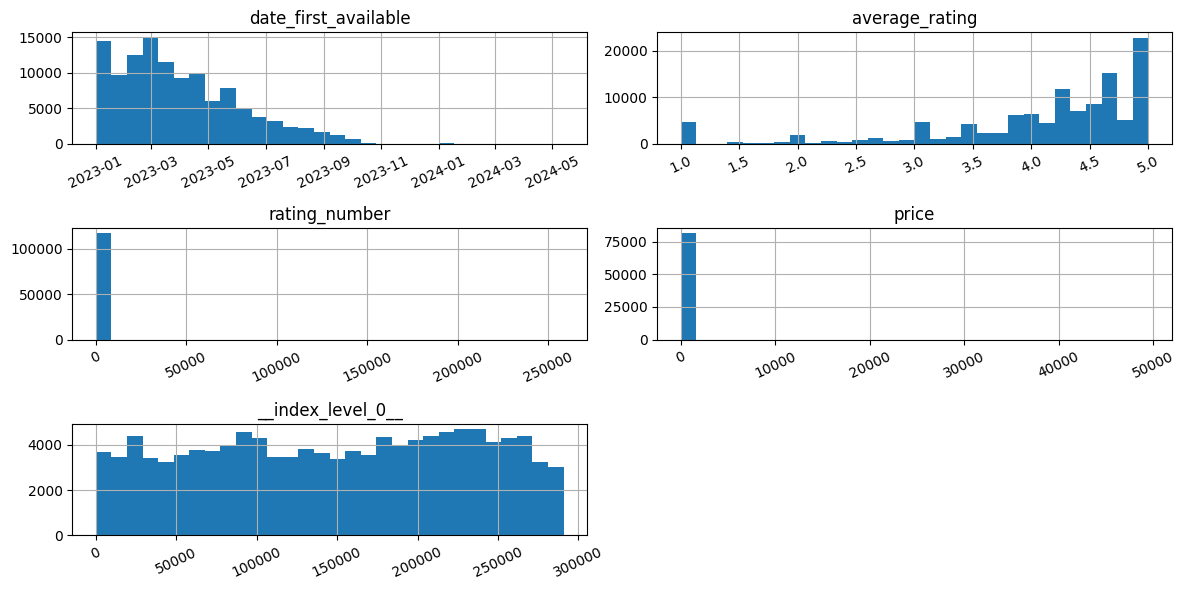

In [10]:
axes = df[num_cols].hist(bins=30, figsize=(12, 6))
for ax in axes.flatten():
    ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

In [11]:
# Пример записей
df[[col for col in df.columns if col != 'embeddings']].sample(5,random_state=RANDOM_SEED)

,parent_asin,date_first_available,title,description,filename,main_category,categories,store,average_rating,rating_number,price,features,details,image,__index_level_0__
59713,B0BYJ27VBB,2023-03-09,"HP EliteBook 640 G9 14"" FHD Business Laptop (I...",HP Sure Sense\nMalware is evolving rapidly and...,meta_Electronics,Computers,"[Electronics, Computers & Accessories, Compute...",HP,4.9,14.0,899.99,"[The HP EliteBook 640 is a cost-effective, pow...","{'Standing screen display size': '14 Inches', ...",https://m.media-amazon.com/images/I/7109YWFIMZ...,154614
107521,B0BVHSQLTN,2023-02-11,"PIGOLDOG Yoga Sock s For Women,Non Slip Skid S...","Material: The Socks made with 85% soft cotton,...",meta_Clothing_Shoes_and_Jewelry,AMAZON FASHION,"[Clothing, Shoes & Jewelry, Sport Specific Clo...",PIGOLDOG,4.8,8.0,16.99,"[85% soft cotton, 15% spandex, 100% silicone g...",{'Package Dimensions': '0.3 x 0.2 x 0.05 inche...,https://m.media-amazon.com/images/I/51MmMn3OYU...,263841
61778,B0BYZ94J4G,2023-03-20,8x6ft Monster Truck Photography Backdrop Car G...,Product Details Material: Soft Fabric/Polyeste...,meta_Electronics,Camera & Photo,"[Electronics, Camera & Photo, Lighting & Studi...",TAUERGULE,4.8,42.0,21.80,[Size:8ft(width) x 6ft(height)/2.4 meter (wide...,{'Product Dimensions': '96 x 72 x 0.01 inches'...,https://m.media-amazon.com/images/I/71jSbK0alV...,160078
116205,B0BYWZLFGL,2023-03-19,"Wwkhhrst Restowipes Headlight Restoration Kit,...","Package - 1 x polishing disc, 10 x wet wipes, ...",meta_Tools_and_Home_Improvement,Automotive,"[Lighting Assemblies & Accessories, Headlight ...",Wwkhhrst,2.4,8.0,NaN,[[Headlight Cleaner Restoration Kit for Car] -...,"{'Manufacturer': 'FSascend', 'Brand': 'Wwkhhrs...",https://m.media-amazon.com/images/I/71FbVqbC+r...,287515
116238,B0C4GHV265,2023-05-06,mignonnememe 6 Tiers Small Bathroom Storage Ca...,Specification\nMaterial: Wood-plastic Composit...,meta_Tools_and_Home_Improvement,None,"[Tools & Home Improvement, Hardware, Bathroom ...",mignonnememe,2.1,3.0,NaN,[【Small Footprint】The compact size of this cab...,"{'Brand': 'Mignonnememe', 'Color': 'White', 'P...",https://m.media-amazon.com/images/I/51ZqGPcLqM...,287651


Посмотрим на длину текстовых данных, чтобы примерно оценть колво токенов

In [12]:
df['description'].str.len().describe()

count    117243.000000
mean        667.650487
std         570.747890
min           1.000000
25%         208.000000
50%         520.000000
75%        1017.500000
max       17217.000000
Name: description, dtype: float64

In [13]:
def trim_text(text):
    return len(text.split())

df['description'].apply(trim_text).describe()

count    117243.000000
mean        106.198519
std          91.894530
min           1.000000
25%          33.000000
50%          82.000000
75%         161.000000
max        2664.000000
Name: description, dtype: float64

In [14]:
df['title'].str.len().describe()

count    117243.000000
mean        119.610723
std          55.567772
min           1.000000
25%          72.000000
50%         120.000000
75%         171.000000
max         499.000000
Name: title, dtype: float64

In [15]:
df['title'].apply(trim_text).describe()

count    117243.000000
mean         18.395793
std           8.728199
min           1.000000
25%          11.000000
50%          18.000000
75%          26.000000
max          86.000000
Name: title, dtype: float64

In [16]:
# пропуски
na_count = df.isna().sum()
na_count[na_count > 0].sort_values()

rating_number        6
store              253
main_category    24805
price            35869
dtype: int64

In [17]:
# последние листовые категории
df['categories'].apply(lambda x: x[-1] if len(x)>0 else None).value_counts()

categories
T-Shirts                            3112
Basic Cases                         2297
Casual                              1025
Posters & Prints                     913
Fashion Sneakers                     886
                                    ... 
Utility Pumps                          1
Die Grinders                           1
Electrode Holders                      1
Dust Collectors & Air Cleaners         1
Water Pumps, Parts & Accessories       1
Name: count, Length: 6989, dtype: int64

In [18]:
# основные категории
ALL_MAIN_CAT = list(df['main_category'].dropna().unique())
df['main_category'].value_counts()

main_category
AMAZON FASHION                  36460
Amazon Home                     13874
Tools & Home Improvement         7945
Automotive                       5980
Cell Phones & Accessories        3471
Health & Personal Care           3416
All Electronics                  3136
Sports & Outdoors                2942
Office Products                  2925
Industrial & Scientific          2460
Pet Supplies                     1907
Computers                        1724
Digital Music                    1379
Handmade                         1127
Arts, Crafts & Sewing             874
Camera & Photo                    842
Musical Instruments               506
Appliances                        312
Home Audio & Theater              218
Video Games                       182
Toys & Games                      146
Appstore for Android              142
Collectibles & Fine Art           114
Car Electronics                    69
All Beauty                         65
GPS & Navigation                   5

In [19]:
# пример инфы о товаре
eval(df['details'].iloc[10])

{'Package Dimensions': '5.56 x 4.93 x 0.16 inches; 1.13 Ounces',
 'Date First Available': 'January 26, 2023',
 'Country of Origin': 'Germany',
 'Number of discs': '1'}

In [20]:
# пример инфы о товаре (видимо доп описание)
df['features'].iloc[1000]

array(['Quality & Maintain: All-Weather wicker and Anti-Rust steel frame make this outdoor patio furniture 6 pieces very durable and sturdy. Breathable 250G polyester Anti-UV and water repellent fabric, against stain, with a zipper for easy cleaning and replacement; with the waterproof Covers, no worry about dust, water, fade, and rust, superbly ensure to last a long time.',
       'Comfortable & Non-slip: Thickened seat cushions(4 inches) with high resilience sponge and bottom anti-slip dotted plastic fabric, anti-slip and practicality are wholly better than lacing or velcro, back cushions filling with PP cotton, which is extraordinarily comfortable and everlasting with front porch furniture. Free Lumbar pillows style randomly.',
       'Highly Adaptable: Outdoor couch set includes patio chairs, outdoor sofa, ottomans, and storage coffee table; styles coverage are diverse and unique. Depending on needs and better space utilization, various layouts and combinations are suitable for any

# Подготовка данных

In [21]:
df = df.dropna()
df = df[(df["description"].str.len() >= 10)&(df["title"].str.len() >= 5)]
df.shape

(66870, 16)

In [22]:
# оставим +-2к строк с равным соотношением категорий
valid_cats = df["main_category"].value_counts()
valid_cats = valid_cats[valid_cats >= 100].index
df = df[df["main_category"].isin(valid_cats)]

N = 2100
sample_per_cat = int(N / len(valid_cats))

df_sample = df.groupby("main_category", group_keys=False).apply(lambda x: x.sample(min(len(x), sample_per_cat), random_state=RANDOM_SEED))

print(f'Категорий: {df_sample["main_category"].nunique()}')
print(f'Размер: {len(df_sample)}')
print(f'Колво на категорию: {df_sample["main_category"].value_counts().iloc[0]}')


Категорий: 22
Размер: 2090
Колво на категорию: 95


In [23]:
def download_image(url, filename):
    try:
        response = requests.get(url, timeout=8)
        response.raise_for_status()
        img = Image.open(BytesIO(response.content)).convert("RGB")
        img.save(filename, format="JPEG")
        return True
    except Exception:
        return False

In [24]:
df_path = './data/amazon_subset.csv'
if not os.path.isfile(df_path):
    save_dir = "./images"
    os.makedirs(save_dir, exist_ok=True)

    paths, status = [], []

    for i, row in tqdm(df_sample.iterrows(), total=len(df_sample)):
        url = row["image"]
        fname = os.path.join(save_dir, f"{i:07d}.jpg")
        ok = download_image(url, fname)
        paths.append(fname if ok else None)
        status.append(ok)

    df_sample["local_image"] = paths
    df_sample["download_ok"] = status
    df_sample.to_csv(df_path, index=True)

df_local = pd.read_csv(df_path)

In [25]:
df_local = df_local[df_local["download_ok"]]

print(f"Скачано успешно: {df_sample.shape[0]}")

Скачано успешно: 2090


# Task №1: Классификация

**Формулировка задачи:**

Определение верхнеуровневой категории товара по изображению, названию и описанию товара.

Использовать узкие категории в такой задаче нереально, тк просто не влезет инструкция в модель. Более того общие категории есть почти у всех товаров, а листовые категории могут отсутствовать, что накладывает дополнительные трудности.

**Сравниваемые модели:**

- Qwen3-VL-4B-Instruct

- InternVL2-4B


In [26]:
# В промпте и при подсчете метрик будут использоватся все возможные верхнеуровневые категории, 
# а не только те, что остались после фильтрации
URL = "http://localhost:9080/v1"
CATEGORY_LIST_STR = '[\"'+'\", \"'.join(ALL_MAIN_CAT)+'\"]'
INPUT_PROMPT = (
    "You are a product classifier for a marketplace catalog. "
    "Given an image, product title and description, determine the main category "
    f"of the item from the provided list. "
    "Respond with exactly one category name, no explanations."
)

def build_prompt_task1(title, description, img_tips=False, max_words=None):
    if max_words is None:
        max_words = len(description.split())
    prompt = (
        f"{INPUT_PROMPT}\n"
        f"Available categories: {CATEGORY_LIST_STR}\n"
        f"Title: {title}\n"
        f"Description: {' '.join(description.split()[:max_words])}\n"
        f"{'Below is the image: ' if img_tips else 'Category: '}"
    )
    return prompt

In [27]:
CATEGORY_LIST_STR

'["Digital Music", "Musical Instruments", "Cell Phones & Accessories", "AMAZON FASHION", "Industrial & Scientific", "All Electronics", "Tools & Home Improvement", "Health & Personal Care", "Amazon Home", "Home Audio & Theater", "Office Products", "Computers", "Arts, Crafts & Sewing", "Sports & Outdoors", "Toys & Games", "Camera & Photo", "Automotive", "Grocery", "Pet Supplies", "Appliances", "Baby", "Appstore for Android", "Software", "Gift Cards", "Sports Collectibles", "Collectibles & Fine Art", "All Beauty", "Handmade", "Video Games", "Car Electronics", "GPS & Navigation", "Collectible Coins", "Entertainment", "Portable Audio & Accessories", "Magazine Subscriptions", "Amazon Fire TV", "Amazon Devices"]'

In [28]:
def classify_product(prompt, image_path, model_name, text_first=False, use_img=True, temperature=0, top_p=1, max_tokens=16, img_size=336):
    try:
        if use_img:
            img = Image.open(image_path).convert("RGB")
            img.thumbnail((img_size,img_size)) # целеноправленно пропорционально сжимаем изображения для уменьшения накладных расходов и уменьшения токенов
            buf = BytesIO()
            img.save(buf, format="JPEG")
            b64_img = base64.b64encode(buf.getvalue()).decode("utf-8")
            # with tempfile.NamedTemporaryFile(suffix=".jpg", delete=False) as tmp:
            #     img.save(tmp, format="JPEG")
            #     tmp_path = tmp.name

        
            if text_first:
                content = [
                    {"type": "text", "text": prompt},
                    # {"type": "image_url", "image_url": {"url": f"file://{tmp_path}"}},
                    {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{b64_img}"}}
                ]
            else:
                content = [
                    {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{b64_img}"}},
                    # {"type": "image_url", "image_url": {"url": f"file://{tmp_path}"}},
                    {"type": "text", "text": prompt}
                ]
        else:
            content = [{"type": "text", "text": prompt}]

        response = client.chat.completions.create(
            model=model_name,
            messages=[
                {
                    "role": "user",
                    "content": content,
                }
            ],
            temperature=temperature,
            max_tokens=max_tokens,
            top_p=top_p
        )

        return response.choices[0].message.content.strip()

    except Exception as e:
        return f"ERROR: {e}"

## Qwen3

Необходимо пере/запустить сервер vLLM:

- `bash start_qwen.sh`

In [29]:
model_name = "Qwen/Qwen3-VL-4B-Instruct"
client = OpenAI(base_url=URL, api_key="EMPTY")

path = f'./data/{model_name.split("/")[0]}_pred.csv'


if not os.path.isfile(path):
    qwen_df = df_local[['image','local_image','title','description', 'main_category']].copy()
    preds = []
    for _, row in tqdm(qwen_df.iterrows(), total=len(qwen_df)):
        input_text = build_prompt_task1(row["title"], row["description"])
        pred = classify_product(input_text, row["local_image"], model_name)
        preds.append(pred)

    qwen_df[f"pred_category"] = preds
    qwen_df.to_csv(path)
else:
    qwen_df = pd.read_csv(path)

In [30]:
qwen_df.head()

,Unnamed: 0,image,local_image,title,description,main_category,pred_category
0,0,https://m.media-amazon.com/images/I/71FvDefh9y...,./images/0014114.jpg,Nayu Feng Shui Pixiu Mantra Ring For Wealth An...,Specification: Material: Copper Color: Vin...,AMAZON FASHION,Health & Personal Care
1,1,https://m.media-amazon.com/images/I/81PwiwtEdA...,./images/0085838.jpg,ZRDZSW 78 Pack Letters & Numbers Shoe Charms f...,These 78 Letters and Numbers Shoes Charms are ...,AMAZON FASHION,Toys & Games
2,2,https://m.media-amazon.com/images/I/51OEM75rm7...,./images/0072822.jpg,925 Sterling Silver Simulated Turquoise Teardr...,ICECARATS DESIGNER JEWELRY 925 STERLING SILVER...,AMAZON FASHION,Handmade
3,3,https://m.media-amazon.com/images/I/51HW3iFte+...,./images/0032281.jpg,Au-TOMOTIVE GOLD Rectangular Wave Key Ring for...,Quickly identified as our wave key fob by the ...,AMAZON FASHION,Automotive
4,4,https://m.media-amazon.com/images/I/61UZb8XM5S...,./images/0089936.jpg,Bella Canvas womens B8800y,"65% polyester, 35% viscose jersey, 32 singles,...",AMAZON FASHION,AMAZON FASHION


In [31]:
invalid_preds = qwen_df[~qwen_df["pred_category"].isin(ALL_MAIN_CAT)]
len(invalid_preds['pred_category'].unique())

1

In [32]:
category_map = {
    "Games": "Video Games"
}

qwen_df["pred_category"] = qwen_df["pred_category"].apply(lambda x: category_map.get(x, x))
invalid_preds = qwen_df[~qwen_df["pred_category"].isin(ALL_MAIN_CAT)]
len(invalid_preds['pred_category'].unique())

0

In [33]:
true_qwen_df = qwen_df[qwen_df["pred_category"].isin(ALL_MAIN_CAT)]

## InternVL2

Необходимо пере/запустить сервер vLLM:

- `bash start_intern.sh`

In [34]:
model_name = "OpenGVLab/InternVL2-4B"
client = OpenAI(base_url=URL, api_key="EMPTY")

path = f'./data/{model_name.split("/")[0]}_pred.csv'


if not os.path.isfile(path):
    intern_df = df_local[['image','local_image','title','description', 'main_category']].copy()
    preds = []
    for _, row in tqdm(intern_df.iterrows(), total=len(intern_df)):
        input_text = build_prompt_task1(row["title"], row["description"], max_words=200) #, img_tips=True
        pred = classify_product(input_text, row["local_image"], model_name) #, text_first=True
        preds.append(pred)

    intern_df[f"pred_category"] = preds
    intern_df.to_csv(path)
else:
    intern_df = pd.read_csv(path)


In [35]:
intern_df.sample(5, random_state=RANDOM_SEED)

,Unnamed: 0,image,local_image,title,description,main_category,pred_category
529,529,https://m.media-amazon.com/images/I/71WYmeVMGj...,./images/0038046.jpg,40 Pcs Pottery Mug Handle Molds Pottery Tools ...,Features: These mug handle molds feature delic...,"Arts, Crafts & Sewing","Arts, Crafts & Sewing"
1455,1455,https://m.media-amazon.com/images/I/71VDgnJdPr...,./images/0000106.jpg,"Guyker Metal Flat Humbucker Cover, Pickup Moun...","Guyker Metal Flat Humbucker Cover, Pickup Moun...",Musical Instruments,Musical Instruments
382,382,https://m.media-amazon.com/images/I/91Fi5pPJOP...,./images/0004978.jpg,Low Power: Battery Charge,Enjoy the better experience in this Low Power:...,Appstore for Android,Toys & Games
585,585,https://m.media-amazon.com/images/I/61Ail8gw35...,./images/0033112.jpg,Splash Guard Fender Liners Shield with Clips C...,Vehicle Compatibility\nCheck the description t...,Automotive,Automotive
1865,1866,https://m.media-amazon.com/images/I/51ZVo0BEwP...,./images/0112862.jpg,Kreg Circular Saw Cutting Bundle - KMA2685 Rip...,"For over 30 years, we have been proudly helpin...",Tools & Home Improvement,Tools & Home Improvement


In [36]:
invalid_preds = intern_df[~intern_df["pred_category"].isin(ALL_MAIN_CAT)]
len(invalid_preds['pred_category'])

136

In [37]:
c_invalid = invalid_preds['pred_category'].value_counts()
c_invalid[c_invalid.values>1]

pred_category
Home                     44
Amazon Fashion           16
Jewelry                  14
Party Supplies            4
Apple                     3
Games & Entertainment     3
Music                     3
Apparel                   3
Science                   2
Party                     2
Print Side                2
Apple Devices             2
Gaming                    2
Name: count, dtype: int64

In [38]:
category_map = {
    "Home": "Amazon Home",
    "Amazon Fashion": "AMAZON FASHION",
    "Jewelry": "Collectibles & Fine Art",
    "Party Supplies": "Arts, Crafts & Sewing",
    "Apple": "Cell Phones & Accessories",
    "Games & Entertainment": "Toys & Games",
    "Music": "Digital Music",
    "Apparel": "AMAZON FASHION",
    "Science": "Industrial & Scientific",
    "Party": "Arts, Crafts & Sewing",
    "Print Side": "Office Products",
    "Apple Devices": "Amazon Devices",
    "Gaming": "Video Games"
}

intern_df["pred_category"] = intern_df["pred_category"].apply(lambda x: category_map.get(x, x))

In [39]:
invalid_preds = intern_df[~intern_df["pred_category"].isin(ALL_MAIN_CAT)]
len(invalid_preds['pred_category'])

36

In [40]:
true_intern_df = intern_df[intern_df["pred_category"].isin(ALL_MAIN_CAT)]

## Метрики

In [41]:
def evaluate_classification(y_true, y_pred, labels=None, plot_cm=True):
    y_true = [str(x).strip() for x in y_true]
    y_pred = [str(x).strip() for x in y_pred]

    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    weighted_f1 = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )[2]

    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {f1:.4f}")
    print(f"Weighted F1: {weighted_f1:.4f}")
    print(f"Precision (macro): {precision:.4f}")
    print(f"Recall (macro): {recall:.4f}")

    if plot_cm:
        cm = confusion_matrix(y_true, y_pred, labels=labels)
        np.fill_diagonal(cm, 0)
        cm_df = pd.DataFrame(cm, index=labels, columns=labels)
        

        plt.figure(figsize=(12, 10))
        ax = sns.heatmap(
            cm_df,
            annot=False,
            fmt='d',
            cmap="Blues",
            cbar=True,
            linewidths=0.5,
            linecolor="gray"
        )
        plt.title("Confusion Matrix (percent per true class)")
        plt.ylabel("True Label")
        plt.xlabel("Predicted Label")
        plt.tight_layout()
        plt.show()


Accuracy: 0.5337
Macro F1: 0.3352
Weighted F1: 0.5334
Precision (macro): 0.3966
Recall (macro): 0.3354


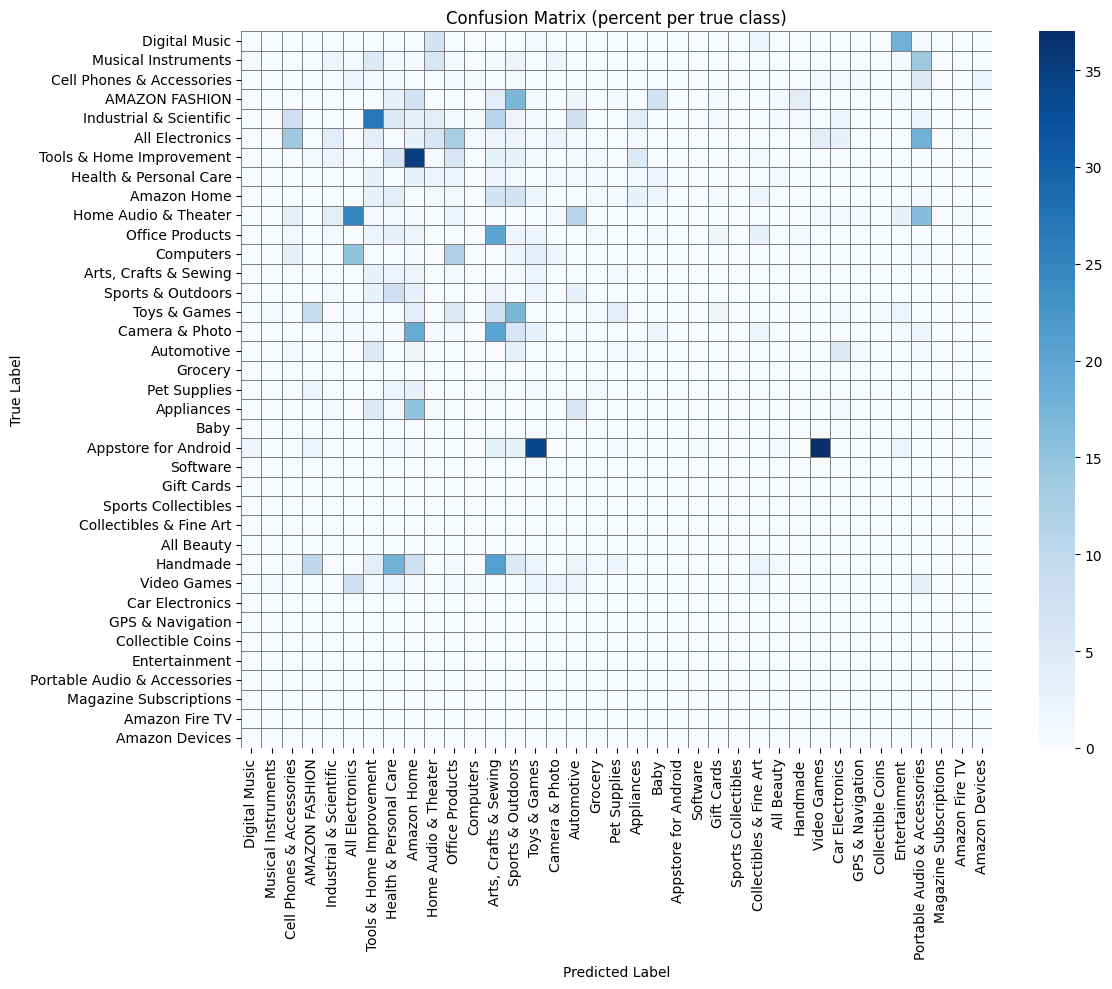

In [42]:
evaluate_classification(true_qwen_df['main_category'], true_qwen_df['pred_category'],ALL_MAIN_CAT);

По результатам тестирования модель Qwen3-4b на задаче классификации угадывает категории более половины товаров (acc=0.53). Также видно, что использование всех доступных категорий (вместо только используемых в текущих данных) дает модели больше возможности для ошибки, тк F1 macro заметно хуже чем F1 weighted (0.35 против 0.53).

Если смотреть на более частые ошибки по матрице ошибок, то модель чаще ошибается в смежных категориях. Например: "Amazon Home" и "Tools & Home Improvement", "Appstore for Android" и "Toys and Games" и "Video Games".

Касательно поведения модель хорошо следует инструкциям. Она ошиблась только в одном примере, указав несуществующий класс.

Accuracy: 0.4735
Macro F1: 0.2883
Weighted F1: 0.4843
Precision (macro): 0.3389
Recall (macro): 0.2818


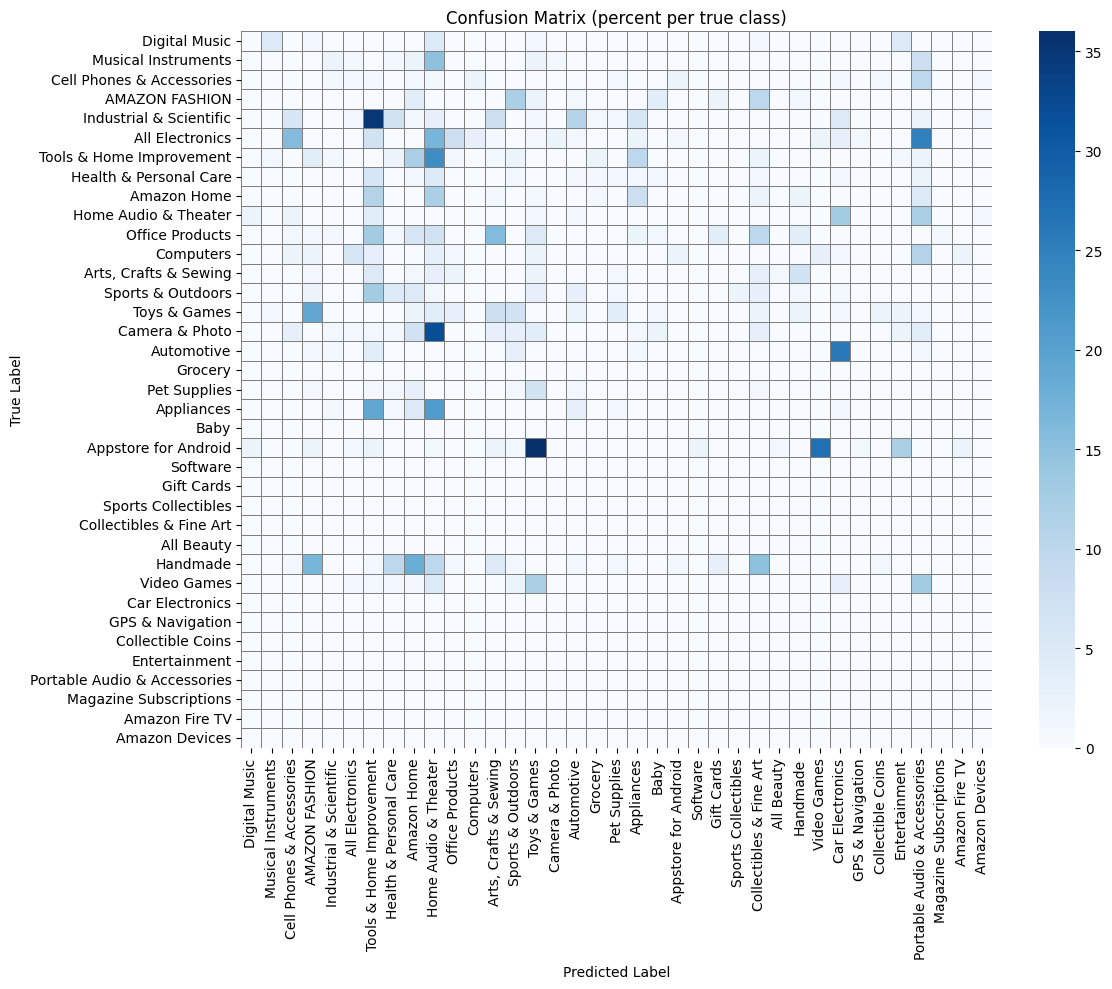

In [43]:
evaluate_classification(true_intern_df['main_category'], true_intern_df['pred_category'],ALL_MAIN_CAT);

Сразу стоит отметит, что в сравнении с Qwen модель InternVL2 хуже следует инструкциям и часто ошибается в предсказании категории, в том плане, что категорий с такой формулировкой нет. 
По метрикам также есть просадка. Касательно природы ошибок, также чаще всего модель ошибается в смежных трудноразличимых категориях.

Данные отличаются в силу постфильтрации. Приведем к одному виду:

In [44]:
common_values = set(true_qwen_df['local_image']) & set(true_intern_df['local_image'])

true_qwen_df_common = true_qwen_df[true_qwen_df['local_image'].isin(common_values)].copy()
true_intern_df_common = true_intern_df[true_intern_df['local_image'].isin(common_values)].copy()

In [45]:
evaluate_classification(true_qwen_df_common['main_category'], true_qwen_df_common['pred_category'],ALL_MAIN_CAT, plot_cm=False);

Accuracy: 0.5334
Macro F1: 0.3351
Weighted F1: 0.5326
Precision (macro): 0.3963
Recall (macro): 0.3354


In [46]:
evaluate_classification(true_intern_df_common['main_category'], true_intern_df_common['pred_category'],ALL_MAIN_CAT, plot_cm=False);

Accuracy: 0.4735
Macro F1: 0.2883
Weighted F1: 0.4843
Precision (macro): 0.3389
Recall (macro): 0.2818


# Вывод

По метрикам и субъективной визуальной оценке, модель Qwen3 показывает лучшие рузльтаты чем InternVL2. Также Qwen3 заметно шустрее и экономичнее по памяти и токенам.

___________

# Task №2: Генерация названий и описаний товаров

Требуется сравнить модели `Qwen3-4b` и `InternVL2-4B` на разных задачах:

- генерация названия по изображению/описанию

- генерация описания по изображению/названию

Ниже происходит инференс на задачах:
- img -> title
- describtion -> title
- img+describtion -> title
- img -> describtion
- img+category -> describtion

Для генерации описания была пропущена комбинация `category -> describtion` тк она бессмысленна.

In [47]:
URL = "http://localhost:9080/v1"
TITLE_PROMPT = (
    "You are a product title generator for an online marketplace. "
    "Given the product image and its short textual description, "
    "write a concise and natural English product title (5–10 words). "
    "Do not add extra details. Do not include category names. "
    "Respond only with the title text. "
)

def build_prompt_title(exp_type, description, img_tips=False):
    on_text = "Given its short textual description, "
    on_img = "Given the product image, "
    on_both = "Given the product image and its short textual description, "

    target_part1 = ''
    target_part2 = ''
    if exp_type == 'text':
        target_part1 = on_text
        target_part2 = f'Description: \"{description}\"\n'
    elif exp_type == 'img':
        target_part1 = on_img
    elif exp_type == 'both':
        target_part1 = on_both
        target_part2 = f'Description: \"{description}\"\n'
    else:
        raise ValueError('exp_type shoold be one of [text, img, both]')

    prompt = (
        "You are a product title generator for an online marketplace. "
        f"{target_part1}"
        "write a concise and natural English product title (5–10 words). "
        "Do not add extra details. Do not include category names. "
        "Respond only with the title text.\n"
        f"{target_part2}"
        f"{'Below is the image:' if img_tips else 'Title: '}"
    )
    return prompt

def build_prompt_description(exp_type, category, img_tips=False):

    prompt = (
        "You are a product description generator."
        "Given the product image and its main category,"
        "generate a natural-sounding, informative 2–3-sentence English description."
        "Focus on product features, materials, or typical use cases."

        "Avoid listing brand names or technical identifiers."
        "Respond only with the description text.\n"
        f"Category: \"{category}\"\n"
        f"{'Below is the image:' if img_tips else 'Description: '}"
    )
    return prompt

In [48]:
def get_pred_with_params(exp_type, df, prompt_builder_f, prompt_target_field, pred_target_field,
                            model_name, max_tokens=64, temperature=0.3, top_p=0.9, use_img=True):
    df_copy = df[['image','local_image','title','description', 'main_category']].copy()
    preds = []
    for _, row in tqdm(df_copy.iterrows(), total=len(df_copy)):

        input_text = prompt_builder_f(exp_type, row[prompt_target_field])
        pred = classify_product(
            input_text, 
            row["local_image"], 
            model_name, 
            max_tokens=max_tokens, 
            temperature=temperature, 
            top_p=top_p, 
            use_img=use_img
        )
        preds.append(pred)

    df_copy[f"pred_{pred_target_field}"] = preds
    return df_copy

## Qwen3

Необходимо пере/запустить сервер vLLM:

- `bash start_qwen.sh`

### img/describtion -> title

**Генерация названий на основе описания**

In [49]:
model_name = "Qwen/Qwen3-VL-4B-Instruct"
client = OpenAI(base_url=URL, api_key="EMPTY")
exp_type = 'text'

path = f'./data/{model_name.split("/")[0]}_pred_title_on_{exp_type}.csv'


if not os.path.isfile(path):
    qwen_title_txt_df = get_pred_with_params(exp_type, df_local, 
                                                build_prompt_title, 'description', 'title',
                                                model_name, max_tokens=64, temperature=0.3, top_p=0.9, use_img=False)
    qwen_title_txt_df.to_csv(path)
else:
    qwen_title_txt_df = pd.read_csv(path)

In [50]:
qwen_title_txt_df.sample(10, random_state=RANDOM_SEED)[['title', 'pred_title']]

,title,pred_title
529,40 Pcs Pottery Mug Handle Molds Pottery Tools ...,Delicate Clay Mug Handle Molds
1455,"Guyker Metal Flat Humbucker Cover, Pickup Moun...",Chrome Humbucker Pickup Covers Set
382,Low Power: Battery Charge,Save Your Phone Before It Dies
585,Splash Guard Fender Liners Shield with Clips C...,Fender Liners for Toyota & Lexus SUVs
1865,Kreg Circular Saw Cutting Bundle - KMA2685 Rip...,Tools for Building Confidence & Accomplishment
1822,Versatile™- PARALLELS-SAMPLE-DIY-6inX6in-Peel ...,Peel & Stick Carpet Tiles for Homes & Offices
237,AwePackage Resealable Clear Poly Bags with 3 L...,Clear Resealable Poly Bags with 3 Language War...
1827,Sasylvia 4 Pcs Black Ebony Lumber Wood Timber ...,Exotic Ebony Wood Handle Plates Set
806,"Trifold Smart Case,Dinines Lightweight Smart C...",Slim Folding Stand Case for All-New 10 & 10 Pl...
51,925 Sterling Silver Screw Top Ash Holder Penda...,Sterling Silver Ash Holder Pendant Charm


**Генерация названий на основе картинки**

In [51]:
model_name = "Qwen/Qwen3-VL-4B-Instruct"
client = OpenAI(base_url=URL, api_key="EMPTY")
exp_type = 'img'

path = f'./data/{model_name.split("/")[0]}_pred_title_on_{exp_type}.csv'


if not os.path.isfile(path):
    qwen_title_img_df = get_pred_with_params(exp_type, df_local, 
                                                build_prompt_title, 'description', 'title',
                                                model_name, max_tokens=64, temperature=0.3, top_p=0.9, use_img=True)
    qwen_title_img_df.to_csv(path)
else:
    qwen_title_img_df = pd.read_csv(path)

In [52]:
qwen_title_img_df.sample(10, random_state=RANDOM_SEED)[['title', 'pred_title']]

,title,pred_title
529,40 Pcs Pottery Mug Handle Molds Pottery Tools ...,Black Furniture Padding Set with Wooden Handles
1455,"Guyker Metal Flat Humbucker Cover, Pickup Moun...",Chrome License Plate Frame Set
382,Low Power: Battery Charge,Battery Charging Game for Kids
585,Splash Guard Fender Liners Shield with Clips C...,Black Mount Brackets with Screws
1865,Kreg Circular Saw Cutting Bundle - KMA2685 Rip...,Blue Precision Cutting Guide Tool
1822,Versatile™- PARALLELS-SAMPLE-DIY-6inX6in-Peel ...,Blue Striped Carpet Sample
237,AwePackage Resealable Clear Poly Bags with 3 L...,Recyclable Plastic Packaging Bag
1827,Sasylvia 4 Pcs Black Ebony Lumber Wood Timber ...,Wooden Guitar Pick Blocks Set
806,"Trifold Smart Case,Dinines Lightweight Smart C...",Black Protective Case for Tablet
51,925 Sterling Silver Screw Top Ash Holder Penda...,Silver Floral Engraved Round Pendant


**Генерация названий на основе описания и картинки**

In [53]:
model_name = "Qwen/Qwen3-VL-4B-Instruct"
client = OpenAI(base_url=URL, api_key="EMPTY")
exp_type = 'both'

path = f'./data/{model_name.split("/")[0]}_pred_title_on_{exp_type}.csv'


if not os.path.isfile(path):
    qwen_title_txt_img_df = get_pred_with_params(exp_type, df_local, 
                                                build_prompt_title, 'description', 'title',
                                                model_name, max_tokens=64, temperature=0.3, top_p=0.9, use_img=True)
    qwen_title_txt_img_df.to_csv(path)
else:
    qwen_title_txt_img_df = pd.read_csv(path)

In [54]:
qwen_title_txt_img_df.sample(10, random_state=RANDOM_SEED)[['title', 'pred_title']]

,title,pred_title
529,40 Pcs Pottery Mug Handle Molds Pottery Tools ...,40 Piece Clay Mug Handle Molds
1455,"Guyker Metal Flat Humbucker Cover, Pickup Moun...",Chrome Guitar Pickup Covers Set
382,Low Power: Battery Charge,Battery Charging Game with Tap & Jump Challenges
585,Splash Guard Fender Liners Shield with Clips C...,Black Fender Liners for Toyota & Lexus
1865,Kreg Circular Saw Cutting Bundle - KMA2685 Rip...,Precision Tools for Building Success
1822,Versatile™- PARALLELS-SAMPLE-DIY-6inX6in-Peel ...,Blue Stripe Peel Stick Carpet Tiles
237,AwePackage Resealable Clear Poly Bags with 3 L...,Resealable Clear Poly Bags with Safety Warnings
1827,Sasylvia 4 Pcs Black Ebony Lumber Wood Timber ...,4 Ebony Wood Knife Handle Scales
806,"Trifold Smart Case,Dinines Lightweight Smart C...",Slim Folding Stand Case for 10 & 10 Plus Tablet
51,925 Sterling Silver Screw Top Ash Holder Penda...,Sterling Silver Ash Holder Pendant Charm


### img+category -> describtion

Проводить генерацию описания только на основе категории не имеет смысла. Потому будет сравнение только на основе картинки и картинки+категории

**Генерация названий на основе картинки**

In [55]:
model_name = "Qwen/Qwen3-VL-4B-Instruct"
client = OpenAI(base_url=URL, api_key="EMPTY")
exp_type = 'img'

path = f'./data/{model_name.split("/")[0]}_pred_description_on_{exp_type}.csv'


if not os.path.isfile(path):
    qwen_description_img_df = get_pred_with_params(exp_type, df_local, 
                                                build_prompt_description, 'main_category', 'description',
                                                model_name, max_tokens=256, temperature=0.5, top_p=0.9, use_img=True)
    qwen_description_img_df.to_csv(path)
else:
    qwen_description_img_df = pd.read_csv(path)

In [56]:
qwen_description_img_df.sample(10, random_state=RANDOM_SEED)[['description', 'pred_description']]

,description,pred_description
529,Features: These mug handle molds feature delic...,"These versatile, black foam patches are perfec..."
1455,"Guyker Metal Flat Humbucker Cover, Pickup Moun...","These sleek, chrome-finished plate covers feat..."
382,Enjoy the better experience in this Low Power:...,"This vibrant, interactive game app invites pla..."
585,Vehicle Compatibility\nCheck the description t...,These durable black mounting brackets are desi...
1865,"For over 30 years, we have been proudly helpin...",This precision tool features a sturdy blue bas...
1822,Introducing Versatile Carpet Tiles - PARALLELS...,"This textured, striped carpet sample offers a ..."
237,[100 Count] of Resealable Clear Poly Bags with...,"This reusable, recyclable bag is designed for ..."
1827,Features: Smooth surface: Our knife handle sc...,"These sleek, dark wood strips are perfect for ..."
806,Case Fits All-New 10 & 10 Plus Tablet (11th Ge...,"This sleek, black protective case offers a sli..."
51,ICECARATS DESIGNER JEWELRY 925 STERLING SILVER...,"This elegant, round pendant features intricate..."


**Генерация названий на основе картинки и категории**

In [57]:
model_name = "Qwen/Qwen3-VL-4B-Instruct"
client = OpenAI(base_url=URL, api_key="EMPTY")
exp_type = 'both'

path = f'./data/{model_name.split("/")[0]}_pred_description_on_{exp_type}.csv'


if not os.path.isfile(path):
    qwen_description_txt_img_df = get_pred_with_params(exp_type, df_local, 
                                                build_prompt_description, 'main_category', 'description',
                                                model_name, max_tokens=256, temperature=0.5, top_p=0.9, use_img=True)
    qwen_description_txt_img_df.to_csv(path)
else:
    qwen_description_txt_img_df = pd.read_csv(path)

In [58]:
qwen_description_txt_img_df.sample(10, random_state=RANDOM_SEED)[['description', 'pred_description']]

,description,pred_description
529,Features: These mug handle molds feature delic...,"These versatile, black felt patches are perfec..."
1455,"Guyker Metal Flat Humbucker Cover, Pickup Moun...","These sleek, chrome-finished plate covers feat..."
382,Enjoy the better experience in this Low Power:...,"This vibrant, interactive game offers a fun an..."
585,Vehicle Compatibility\nCheck the description t...,These durable black mounting brackets are desi...
1865,"For over 30 years, we have been proudly helpin...",This precision tool features a sturdy blue bas...
1822,Introducing Versatile Carpet Tiles - PARALLELS...,"This textured, striped carpet sample offers a ..."
237,[100 Count] of Resealable Clear Poly Bags with...,This recyclable plastic bag is designed for sa...
1827,Features: Smooth surface: Our knife handle sc...,"These sleek, dark wood strips are perfect for ..."
806,Case Fits All-New 10 & 10 Plus Tablet (11th Ge...,"This sleek, black protective case offers a stu..."
51,ICECARATS DESIGNER JEWELRY 925 STERLING SILVER...,"This elegant, round pendant features intricate..."


## InternVL2

Необходимо пере/запустить сервер vLLM:

- `bash start_intern.sh`

### img/describtion -> title

**Генерация названий на основе описания**

In [59]:
model_name = "OpenGVLab/InternVL2-4B"
client = OpenAI(base_url=URL, api_key="EMPTY")
exp_type = 'text'

path = f'./data/{model_name.split("/")[0]}_pred_title_on_{exp_type}.csv'


if not os.path.isfile(path):
    intern_title_txt_df = get_pred_with_params(exp_type, df_local, 
                                                build_prompt_title, 'description', 'title',
                                                model_name, max_tokens=64, temperature=0.3, top_p=0.9, use_img=False)
    intern_title_txt_df.to_csv(path)
else:
    intern_title_txt_df = pd.read_csv(path)

In [60]:
intern_title_txt_df.sample(10, random_state=RANDOM_SEED)[['title', 'pred_title']]

,title,pred_title
529,40 Pcs Pottery Mug Handle Molds Pottery Tools ...,Delicate Pottery Mug Handle Molds
1455,"Guyker Metal Flat Humbucker Cover, Pickup Moun...",Guyker Metal Flat Humbucker Cover
382,Low Power: Battery Charge,Low Power: Battery Charge Game
585,Splash Guard Fender Liners Shield with Clips C...,Fender Liner Installation Kit
1865,Kreg Circular Saw Cutting Bundle - KMA2685 Rip...,"""Empower Your Building Journey with Our Accomp..."
1822,Versatile™- PARALLELS-SAMPLE-DIY-6inX6in-Peel ...,Versatile Carpet Tiles - Durable and Easy to I...
237,AwePackage Resealable Clear Poly Bags with 3 L...,Resealable Clear Poly Bags with Suffocation Wa...
1827,Sasylvia 4 Pcs Black Ebony Lumber Wood Timber ...,Elegant Black Ebony Wood Handle Plates
806,"Trifold Smart Case,Dinines Lightweight Smart C...",All-New 10 & 10 Plus Tablet Case
51,925 Sterling Silver Screw Top Ash Holder Penda...,IceCarats Ash Holder Pendant Necklace


**Генерация названий на основе картинки**

In [61]:
model_name = "OpenGVLab/InternVL2-4B"
client = OpenAI(base_url=URL, api_key="EMPTY")
exp_type = 'img'

path = f'./data/{model_name.split("/")[0]}_pred_title_on_{exp_type}.csv'


if not os.path.isfile(path):
    intern_title_img_df = get_pred_with_params(exp_type, df_local, 
                                                build_prompt_title, 'description', 'title',
                                                model_name, max_tokens=64, temperature=0.3, top_p=0.9, use_img=True)
    intern_title_img_df.to_csv(path)
else:
    intern_title_img_df = pd.read_csv(path)

In [62]:
intern_title_img_df.sample(10, random_state=RANDOM_SEED)[['title', 'pred_title']]

,title,pred_title
529,40 Pcs Pottery Mug Handle Molds Pottery Tools ...,"""Elegant Black Leather Dress Shoes with Wooden..."
1455,"Guyker Metal Flat Humbucker Cover, Pickup Moun...",Stainless Steel Bumper Plate
382,Low Power: Battery Charge,Interactive Science Experiment Kit
585,Splash Guard Fender Liners Shield with Clips C...,"""5-Piece Car Bumper Kit with Mounting Brackets"""
1865,Kreg Circular Saw Cutting Bundle - KMA2685 Rip...,"""Precision Level Tool for Accurate Measurements"""
1822,Versatile™- PARALLELS-SAMPLE-DIY-6inX6in-Peel ...,Sample Textured Fabric
237,AwePackage Resealable Clear Poly Bags with 3 L...,"""Recyclable Bag Not for Children"""
1827,Sasylvia 4 Pcs Black Ebony Lumber Wood Timber ...,Natural Wooden Strips
806,"Trifold Smart Case,Dinines Lightweight Smart C...","""Compact Tablet with Slim Case"""
51,925 Sterling Silver Screw Top Ash Holder Penda...,Silver Butterfly Pendant


**Генерация названий на основе картинки и описания**

In [63]:
model_name = "OpenGVLab/InternVL2-4B"
client = OpenAI(base_url=URL, api_key="EMPTY")
exp_type = 'both'

path = f'./data/{model_name.split("/")[0]}_pred_title_on_{exp_type}.csv'


if not os.path.isfile(path):
    intern_title_txt_img_df = get_pred_with_params(exp_type, df_local, 
                                                build_prompt_title, 'description', 'title',
                                                model_name, max_tokens=64, temperature=0.3, top_p=0.9, use_img=True)
    intern_title_txt_img_df.to_csv(path)
else:
    intern_title_txt_img_df = pd.read_csv(path)

In [64]:
intern_title_txt_img_df.sample(10, random_state=RANDOM_SEED)[['title', 'pred_title']]

,title,pred_title
529,40 Pcs Pottery Mug Handle Molds Pottery Tools ...,Delicate Clay Mug Handle Molds
1455,"Guyker Metal Flat Humbucker Cover, Pickup Moun...",Guyker Metal Flat Humbucker Cover
382,Low Power: Battery Charge,Low Power: Battery Charge Game
585,Splash Guard Fender Liners Shield with Clips C...,Fender Liner for Toyota and Lexus SUVs
1865,Kreg Circular Saw Cutting Bundle - KMA2685 Rip...,"""Experience the Joy of Building with Our Relia..."
1822,Versatile™- PARALLELS-SAMPLE-DIY-6inX6in-Peel ...,"Versatile Carpet Tiles - Durable, Easy Install..."
237,AwePackage Resealable Clear Poly Bags with 3 L...,100 Count Clear Poly Bags with Suffocation War...
1827,Sasylvia 4 Pcs Black Ebony Lumber Wood Timber ...,"""Exquisite Black Ebony Wood Handles with Smoot..."
806,"Trifold Smart Case,Dinines Lightweight Smart C...",All-New 10 & 10 Plus Tablet Case
51,925 Sterling Silver Screw Top Ash Holder Penda...,Ash Holder Pendant Necklace


### img+category -> describtion

Проводить генерацию описания только на основе категории не имеет смысла. Потому будет сравнение только на основе картинки и картинки+категории

**Генерация названий на основе картинки**

In [65]:
model_name = "OpenGVLab/InternVL2-4B"
client = OpenAI(base_url=URL, api_key="EMPTY")
exp_type = 'img'

path = f'./data/{model_name.split("/")[0]}_pred_description_on_{exp_type}.csv'


if not os.path.isfile(path):
    intern_description_img_df = get_pred_with_params(exp_type, df_local, 
                                                build_prompt_description, 'main_category', 'description',
                                                model_name, max_tokens=256, temperature=0.5, top_p=0.9, use_img=True)
    intern_description_img_df.to_csv(path)
else:
    intern_description_img_df = pd.read_csv(path)

In [66]:
intern_description_img_df.sample(10, random_state=RANDOM_SEED)[['description', 'pred_description']]

,description,pred_description
529,Features: These mug handle molds feature delic...,These black felt pencil sharpeners are handcra...
1455,"Guyker Metal Flat Humbucker Cover, Pickup Moun...","These are two sleek, metallic guitar pickguard..."
382,Enjoy the better experience in this Low Power:...,This colorful and interactive game features a ...
585,Vehicle Compatibility\nCheck the description t...,This automotive product features a pair of dur...
1865,"For over 30 years, we have been proudly helpin...",This tool is designed for precision alignment ...
1822,Introducing Versatile Carpet Tiles - PARALLELS...,"This is a durable and sturdy hammer, perfect f..."
237,[100 Count] of Resealable Clear Poly Bags with...,This Amazon Home product is a versatile and st...
1827,Features: Smooth surface: Our knife handle sc...,These wooden planks are ideal for home improve...
806,Case Fits All-New 10 & 10 Plus Tablet (11th Ge...,This sleek tablet features a vibrant display w...
51,ICECARATS DESIGNER JEWELRY 925 STERLING SILVER...,This stylish pendant features a delicate silve...


**Генерация названий на основе картинки и категори**

In [67]:
model_name = "OpenGVLab/InternVL2-4B"
client = OpenAI(base_url=URL, api_key="EMPTY")
exp_type = 'both'

path = f'./data/{model_name.split("/")[0]}_pred_description_on_{exp_type}.csv'


if not os.path.isfile(path):
    intern_description_txt_img_df = get_pred_with_params(exp_type, df_local, 
                                                build_prompt_description, 'main_category', 'description',
                                                model_name, max_tokens=256, temperature=0.5, top_p=0.9, use_img=True)
    intern_description_txt_img_df.to_csv(path)
else:
    intern_description_txt_img_df = pd.read_csv(path)

In [68]:
intern_description_txt_img_df.sample(10, random_state=RANDOM_SEED)[['description', 'pred_description']]

,description,pred_description
529,Features: These mug handle molds feature delic...,These black and white patterned paper shapes a...
1455,"Guyker Metal Flat Humbucker Cover, Pickup Moun...",This set of metal guitar pickguards is crafted...
382,Enjoy the better experience in this Low Power:...,Experience the convenience of managing your ap...
585,Vehicle Compatibility\nCheck the description t...,"This automotive product features a durable, bl..."
1865,"For over 30 years, we have been proudly helpin...",This tool is designed for precise cutting and ...
1822,Introducing Versatile Carpet Tiles - PARALLELS...,"This is a durable and high-quality tool, perfe..."
237,[100 Count] of Resealable Clear Poly Bags with...,This Amazon Home product features a durable an...
1827,Features: Smooth surface: Our knife handle sc...,These durable wooden planks are ideal for vari...
806,Case Fits All-New 10 & 10 Plus Tablet (11th Ge...,This sleek and modern cell phone comes with a ...
51,ICECARATS DESIGNER JEWELRY 925 STERLING SILVER...,This elegant silver pendant features a delicat...


## Замер метрик

In [69]:
def compute_bleu(val, ref_col="title"):
    reference = val[ref_col]
    hypothesis = val[f'pred_{ref_col}']
    ref_tokens = [reference.split()]
    hyp_tokens = hypothesis.split()
    return sentence_bleu(ref_tokens, hyp_tokens,
                         smoothing_function=SmoothingFunction().method1)


scorer = rouge_scorer.RougeScorer(["rouge1", "rougeL"], use_stemmer=True)
def compute_rouge(val, ref_col="title"):
    reference = val[ref_col]
    hypothesis = val[f'pred_{ref_col}']
    scores = scorer.score(reference, hypothesis)
    return {m: scores[m].fmeasure for m in ["rouge1", "rougeL"]}

text_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
def compute_textsim(val, ref_col="title"):
    reference = val[ref_col]
    hypothesis = val[f'pred_{ref_col}']
    emb_ref = text_model.encode(reference, convert_to_tensor=True, normalize_embeddings=True)
    emb_hyp = text_model.encode(hypothesis, convert_to_tensor=True, normalize_embeddings=True)
    return util.cos_sim(emb_ref, emb_hyp).item()


def get_dataset_metrics(df, ref_col="title"):
    df["bleu"] = df.apply(lambda x: compute_bleu(x, ref_col), axis=1)

    rouge_vals = df.apply(lambda x: compute_rouge(x, ref_col), axis=1)
    df["rouge1"] = [r["rouge1"] for r in rouge_vals]
    df["rougeL"] = [r["rougeL"] for r in rouge_vals]

    print("Средние метрики по датасету:")
    print(f"BLEU:    {df['bleu'].mean():.4f}")
    print(f"ROUGE-1: {df['rouge1'].mean():.4f}")
    print(f"ROUGE-L: {df['rougeL'].mean():.4f}")

    df["textsim"] = df.apply(lambda x: compute_textsim(x, ref_col), axis=1)
    print(f"TextSim: {df['textsim'].mean():.4f}")

    return df

### Qwen3

description -> title

In [70]:
qwen_title_txt_df_metrics = get_dataset_metrics(qwen_title_txt_df, 'title')

Средние метрики по датасету:
BLEU:    0.0273
ROUGE-1: 0.3098
ROUGE-L: 0.2728
TextSim: 0.6081


image -> title

In [71]:
qwen_title_img_df_metrics = get_dataset_metrics(qwen_title_img_df, 'title')

Средние метрики по датасету:
BLEU:    0.0191
ROUGE-1: 0.2439
ROUGE-L: 0.2152
TextSim: 0.5363


description+image -> title

In [72]:
qwen_title_txt_img_df_metrics = get_dataset_metrics(qwen_title_txt_img_df, 'title')

Средние метрики по датасету:
BLEU:    0.0327
ROUGE-1: 0.3404
ROUGE-L: 0.2988
TextSim: 0.6358


image -> description

In [73]:
qwen_description_img_df_metrics = get_dataset_metrics(qwen_description_img_df, 'description')

Средние метрики по датасету:
BLEU:    0.0035
ROUGE-1: 0.1640
ROUGE-L: 0.0981
TextSim: 0.4879


category+image -> description

In [74]:
qwen_description_txt_img_df_metrics = get_dataset_metrics(qwen_description_txt_img_df, 'description')

Средние метрики по датасету:
BLEU:    0.0034
ROUGE-1: 0.1647
ROUGE-L: 0.0979
TextSim: 0.4875


### InternVL2

description -> title

In [75]:
intern_title_txt_df_metrics = get_dataset_metrics(intern_title_txt_df, 'title')

Средние метрики по датасету:
BLEU:    0.0432
ROUGE-1: 0.3126
ROUGE-L: 0.2870
TextSim: 0.6153


image -> title

In [76]:
intern_title_img_df_metrics = get_dataset_metrics(intern_title_img_df, 'title')

Средние метрики по датасету:
BLEU:    0.0111
ROUGE-1: 0.1557
ROUGE-L: 0.1423
TextSim: 0.4268


description+image -> title

In [77]:
intern_title_txt_img_df_metrics = get_dataset_metrics(intern_title_txt_img_df, 'title')

Средние метрики по датасету:
BLEU:    0.0438
ROUGE-1: 0.3272
ROUGE-L: 0.2989
TextSim: 0.6285


image -> description

In [78]:
intern_description_img_df_metrics = get_dataset_metrics(intern_description_img_df, 'description')

Средние метрики по датасету:
BLEU:    0.0032
ROUGE-1: 0.1544
ROUGE-L: 0.0943
TextSim: 0.3872


category+image -> description

In [79]:
intern_description_txt_img_df_metrics = get_dataset_metrics(intern_description_txt_img_df, 'description')

Средние метрики по датасету:
BLEU:    0.0031
ROUGE-1: 0.1543
ROUGE-L: 0.0943
TextSim: 0.3926


## LLM as Judge

In [80]:
URL = "http://localhost:9080/v1"

def build_prompt_judge(gt, pred, img_tips=False):
    prompt = (
        "You are an impartial evaluator of product text quality.\n"
        "You will be given two texts:\n"
        "- Reference (the correct human-written text)\n"
        "- Prediction (the AI-generated text)\n\n"
        "Evaluate how similar and appropriate the prediction is compared to the reference.\n"
        "Score from 0 to 5:\n"
        "0 = completely wrong or unrelated\n"
        "1 = poor match\n"
        "2 = partially relevant but inaccurate\n"
        "3 = mostly correct with minor errors\n"
        "4 = very close, natural and relevant\n"
        "5 = perfect or nearly identical meaning\n\n"
        "Return **only the number** (0–5) with no text or explanation.\n\n"
        f"Reference:\n{gt}\n\n"
        f"Prediction:\n{pred}"
    )
    return prompt

def get_pred_from_judge(df, prompt_builder_f, prompt_target_field, model_name):
    preds = []
    for _, row in tqdm(df.iterrows(), total=len(df)):

        input_text = prompt_builder_f(row[prompt_target_field], row[f'pred_{prompt_target_field}'])
        pred = classify_product(
            input_text, 
            '', 
            model_name, 
            max_tokens=1, 
            temperature=0, 
            top_p=1, 
            use_img=False
        )
        preds.append(pred)

    df[f"llm_judge"] = preds
    return df

Оценка генераций проводится через `Qwen3-VL-4B-Instruct`. То что она будет проверять свои же ответы не является ошибкой, тк она решает задачу сравнения ответов (без доп модальностей), а проверяемые модели решали задачу написания названия или описания.

Необходимо пере/запустить сервер vLLM:

- `bash start_qwen.sh`

In [106]:
model_name = "Qwen/Qwen3-VL-4B-Instruct"
client = OpenAI(base_url=URL, api_key="EMPTY")

In [82]:
if os.path.isfile("./data_judge/qwen_title_txt.csv"):
    qwen_title_txt_df_judge = pd.read_csv("./data_judge/qwen_title_txt.csv")
else:
    qwen_title_txt_df_judge = get_pred_from_judge(qwen_title_txt_df.copy(), build_prompt_judge, "title", model_name)
    qwen_title_txt_df_judge.to_csv('./data_judge/qwen_title_txt.csv')

if os.path.isfile("./data_judge/qwen_title_txt_img.csv"):
    qwen_title_txt_img_df_judge = pd.read_csv("./data_judge/qwen_title_txt_img.csv")
else:
    qwen_title_txt_img_df_judge = get_pred_from_judge(qwen_title_txt_img_df.copy(), build_prompt_judge, "title", model_name)
    qwen_title_txt_img_df_judge.to_csv('./data_judge/qwen_title_txt_img.csv')

if os.path.isfile("./data_judge/qwen_title_img.csv"):
    qwen_title_img_df_judge = pd.read_csv("./data_judge/qwen_title_img.csv")
else:
    qwen_title_img_df_judge = get_pred_from_judge(qwen_title_img_df.copy(), build_prompt_judge, "title", model_name)
    qwen_title_img_df_judge.to_csv('./data_judge/qwen_title_img.csv')

if os.path.isfile("./data_judge/qwen_description_img.csv"):
    qwen_description_img_df_judge = pd.read_csv("./data_judge/qwen_description_img.csv")
else:
    qwen_description_img_df_judge = get_pred_from_judge(qwen_description_img_df.copy(), build_prompt_judge, "description", model_name)
    qwen_description_img_df_judge.to_csv('./data_judge/qwen_description_img.csv')

if os.path.isfile("./data_judge/qwen_description_txt_img.csv"):
    qwen_description_txt_img_df_judge = pd.read_csv("./data_judge/qwen_description_txt_img.csv")
else:
    qwen_description_txt_img_df_judge = get_pred_from_judge(qwen_description_txt_img_df.copy(), build_prompt_judge, "description", model_name)
    qwen_description_txt_img_df_judge.to_csv('./data_judge/qwen_description_txt_img.csv')


100%|██████████| 2089/2089 [02:31<00:00, 13.80it/s]


In [108]:
if os.path.isfile("./data_judge/intern_title_txt.csv"):
    intern_title_txt_df_judge = pd.read_csv("./data_judge/intern_title_txt.csv")
else:
    intern_title_txt_df_judge = get_pred_from_judge(intern_title_txt_df.copy(), build_prompt_judge, "title", model_name)
    intern_title_txt_df_judge.to_csv('./data_judge/intern_title_txt.csv')

if os.path.isfile("./data_judge/intern_title_txt_img.csv"):
    intern_title_txt_img_df_judge = pd.read_csv("./data_judge/intern_title_txt_img.csv")
else:
    intern_title_txt_img_df_judge = get_pred_from_judge(intern_title_txt_img_df.copy(), build_prompt_judge, "title", model_name)
    intern_title_txt_img_df_judge.to_csv('./data_judge/intern_title_txt_img.csv')

if os.path.isfile("./data_judge/intern_title_img.csv"):
    intern_title_img_df_judge = pd.read_csv("./data_judge/intern_title_img.csv")
else:
    intern_title_img_df_judge = get_pred_from_judge(intern_title_img_df.copy(), build_prompt_judge, "title", model_name)
    intern_title_img_df_judge.to_csv('./data_judge/intern_title_img.csv')

if os.path.isfile("./data_judge/intern_description_img.csv"):
    intern_description_img_df_judge = pd.read_csv("./data_judge/intern_description_img.csv")
else:
    intern_description_img_df_judge = get_pred_from_judge(intern_description_img_df.copy(), build_prompt_judge, "description", model_name)
    intern_description_img_df_judge.to_csv('./data_judge/intern_description_img.csv')

if os.path.isfile("./data_judge/intern_description_txt_img.csv"):
    intern_description_txt_img_df_judge = pd.read_csv("./data_judge/intern_description_txt_img.csv")
else:
    intern_description_txt_img_df_judge = get_pred_from_judge(intern_description_txt_img_df.copy(), build_prompt_judge, "description", model_name)
    intern_description_txt_img_df_judge.to_csv('./data_judge/intern_description_txt_img.csv')


100%|██████████| 2089/2089 [02:30<00:00, 13.88it/s]


In [109]:
def plot_llm_judge_scores(task_list, title):
    n = len(task_list)
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle(title, fontsize=16, fontweight="bold")

    for idx, (df, task_name, label) in enumerate(task_list):
        row = 0 if idx < 3 else 1
        col = idx if idx < 3 else idx - 3
        ax = axes[row, col]

        if "llm_judge" not in df.columns:
            ax.axis("off")
            continue

        scores = pd.to_numeric(df["llm_judge"], errors="coerce")
        valid_scores = scores.dropna()

        if valid_scores.empty:
            ax.text(0.5, 0.5, "no valid data", ha="center", va="center", fontsize=10)
            ax.axis("off")
            continue

        valid_scores.hist(ax=ax, bins=np.arange(-0.5, 6.5, 1), rwidth=0.8, color="#4C72B0")
        ax.set_title(label, fontsize=12)
        ax.set_xlabel("Score (0–5)")
        ax.set_ylabel("Count")
        ax.set_xticks(range(6))
        ax.grid(alpha=0.3)

    for i in range(n, 6):
        row, col = (0 if i < 3 else 1), (i if i < 3 else i - 3)
        axes[row, col].axis("off")

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

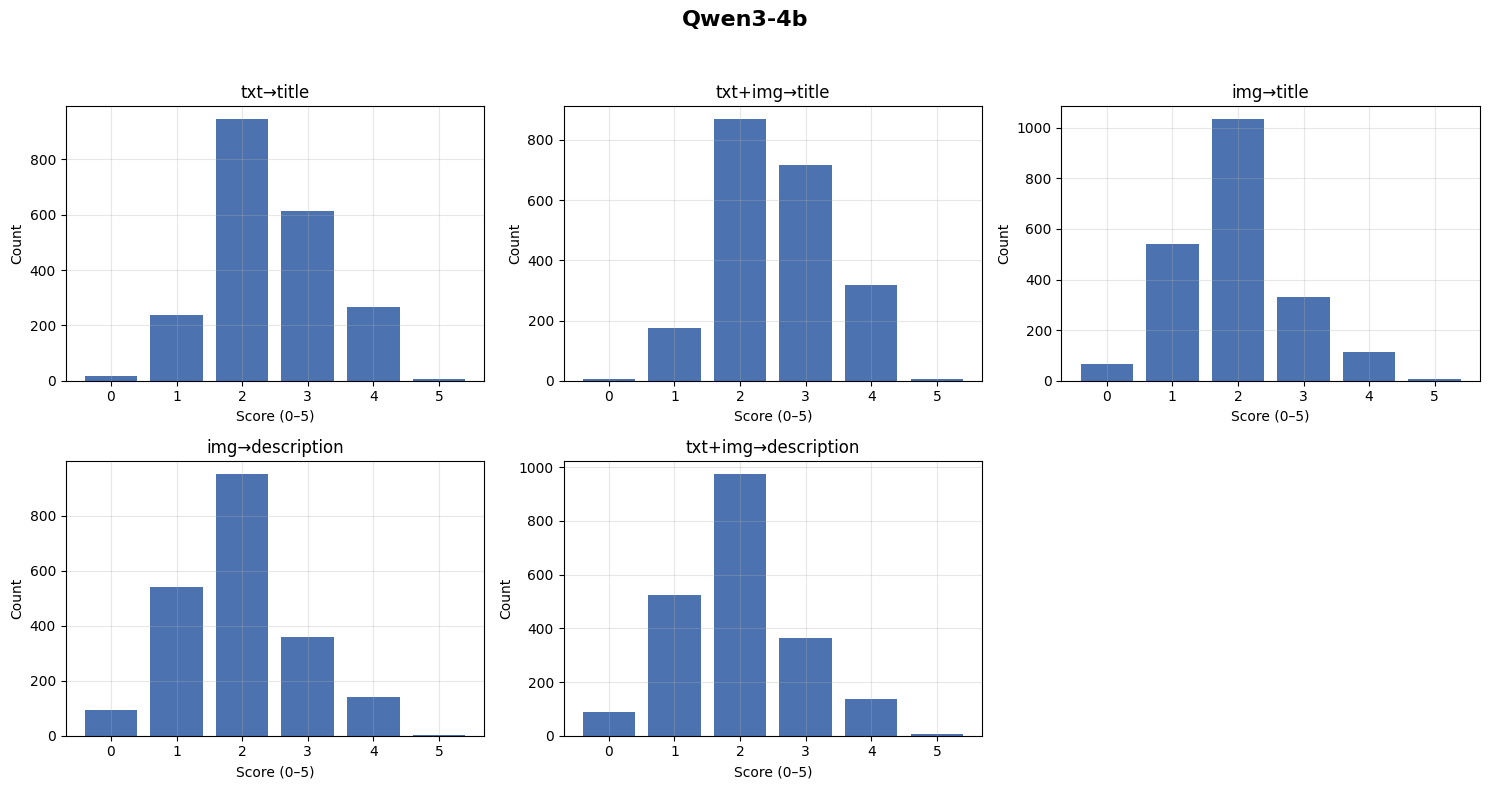

In [110]:
tasks = [
    (qwen_title_txt_df_judge, "title_txt", "txt→title"),
    (qwen_title_txt_img_df_judge, "title_txt_img", "txt+img→title"),
    (qwen_title_img_df_judge, "title_img", "img→title"),
    (qwen_description_img_df_judge, "description_img", "img→description"),
    (qwen_description_txt_img_df_judge, "description_txt_img", "txt+img→description"),
]

plot_llm_judge_scores(tasks, 'Qwen3-4b')


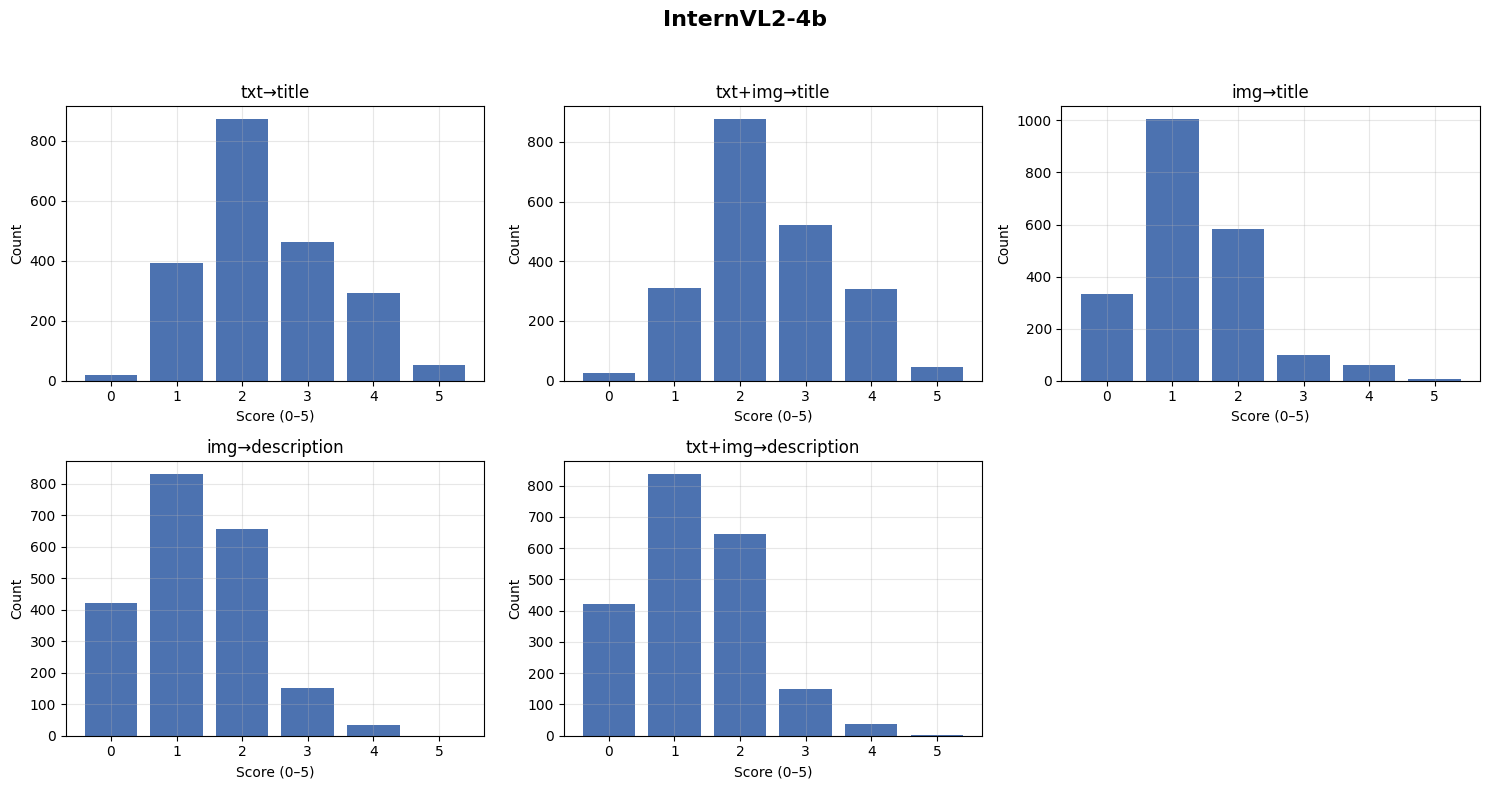

In [111]:
intern_tasks = [
    (intern_title_txt_df_judge, "title_txt", "txt→title"),
    (intern_title_txt_img_df_judge, "title_txt_img", "txt+img→title"),
    (intern_title_img_df_judge, "title_img", "img→title"),
    (intern_description_img_df_judge, "description_img", "img→description"),
    (intern_description_txt_img_df_judge, "description_txt_img", "txt+img→description"),
]

plot_llm_judge_scores(intern_tasks, 'InternVL2-4b')


In [112]:
all_tasks = [
    (qwen_title_txt_df_judge, "Qwen3-4B", "desc->title"),
    (qwen_title_txt_img_df_judge, "Qwen3-4B", "desc+img->title"),
    (qwen_title_img_df_judge, "Qwen3-4B", "img->title"),
    (qwen_description_img_df_judge, "Qwen3-4B", "img->desc"),
    (qwen_description_txt_img_df_judge, "Qwen3-4B", "cat+img->desc"),
    (intern_title_txt_df_judge, "InternVL2-4B", "desc->title"),
    (intern_title_txt_img_df_judge, "InternVL2-4B", "desc+img->title"),
    (intern_title_img_df_judge, "InternVL2-4B", "img->title"),
    (intern_description_img_df_judge, "InternVL2-4B", "img->desc"),
    (intern_description_txt_img_df_judge, "InternVL2-4B", "cat+img->desc"),
]

rows = []
for df, model, task in all_tasks:
    mean_score = pd.to_numeric(df["llm_judge"], errors="coerce").mean()
    rows.append({"Model": model, "Task": task, "MeanScore": mean_score})

df_summary = pd.DataFrame(rows).pivot(index="Model", columns="Task", values="MeanScore")
df_summary = df_summary.reindex(columns=["desc->title", "desc+img->title", "img->title", "img->desc", "cat+img->desc"])
styled = (
    df_summary.round(3)
    .style.highlight_max(axis=0, color="lightgreen")
    .format(precision=3, na_rep="-")
)

display(styled)

Task,desc->title,desc+img->title,img->title,img->desc,cat+img->desc
Model,,,,,
InternVL2-4B,2.372,2.436,1.316,1.306,1.305
Qwen3-4B,2.431,2.566,1.953,1.963,1.975


## Сводка по метрикам

**Генерация названия**

| Модель   | Осн.      | BLEU                                     | ROUGE-1                                  | ROUGE-L                                  | TextSim                                  | Judge |
| -------- | ---------- | ---------------------------------------- | ---------------------------------------- | ---------------------------------------- | ---------------------------------------- | ------ |
| Qwen     | desc→title | 0.0273                                   | 0.3098                                   | 0.2728                                   | 0.6081                                   | <span style="color:green;">2.431</span> |
| Qwen     | desc+img→title | 0.0327                                   | <span style="color:green;">0.3404</span> | 0.2988                                   | <span style="color:green;">0.6358</span> | <span style="color:green;">2.566</span> |
| Qwen     | img→title  | 0.0191                                   | 0.2439                                   | 0.2152                                   | 0.5363                                   | 1.953  |
| InternVL | desc→title | 0.0432                                   | 0.3126                                   | 0.2870                                   | 0.6153                                   | 2.372  |
| InternVL | desc+img→title | <span style="color:green;">0.0438</span> | 0.3272                                   | <span style="color:green;">0.2989</span> | 0.6285                                   | 2.436  |
| InternVL | img→title  | <span style="color:red;">0.0111</span>   | <span style="color:red;">0.1557</span>   | <span style="color:red;">0.1423</span>   | <span style="color:red;">0.4268</span>   | <span style="color:red;">1.316</span>   |


**Генерация описания**

| Модель   | Осн.        | BLEU                                     | ROUGE-1                                  | ROUGE-L                                  | TextSim                                  | Judge |
| -------- | ------------ | ---------------------------------------- | ---------------------------------------- | ---------------------------------------- | ---------------------------------------- | ------ |
| Qwen     | img→desc     | 0.0191                                   | 0.2439                                   | 0.2152                                   | 0.5363                                   | <span style="color:green;">1.963</span> |
| Qwen     | cat+img→desc | 0.0034                                   | <span style="color:green;">0.1647</span> | 0.0979                                   | 0.4875                                   | <span style="color:green;">1.975</span> |
| InternVL | img→desc     | 0.0032                                   | 0.1544                                   | 0.0943                                   | 0.3872                                   | <span style="color:red;">1.306</span>   |
| InternVL | cat+img→desc | <span style="color:red;">0.0031</span>   | <span style="color:red;">0.1543</span>   | <span style="color:red;">0.0943</span>   | <span style="color:red;">0.3926</span>   | <span style="color:red;">1.305</span>   |


### Вывод

Опираясь на метрики однозначно можно сказать только, что с генерацией описаний (больших текстов), лучше справляется модель Qwen3-4b. Причем интересно заметить, что результат генерации описания лучше без использования текстовой категории, хотя по сути это дополнительная полезная информация.

Касательно генерации коротких названий сложно сделать однозначный вывод. Метрика, полученная из LLM-as-judge, показывает, что Qwen3-4b справляется лучше. Однако, автоматические метрики довольно близки, особенно при использовании всех модальностей (картинка, описание).

Стоит отметить, что генерация названия довольно непростая задача в данном контексте. Так как зачастую название может быть уникальным или техническим. Потому автоматические метрики не могут в целом описать качество модели на такой задаче.